V-plot 

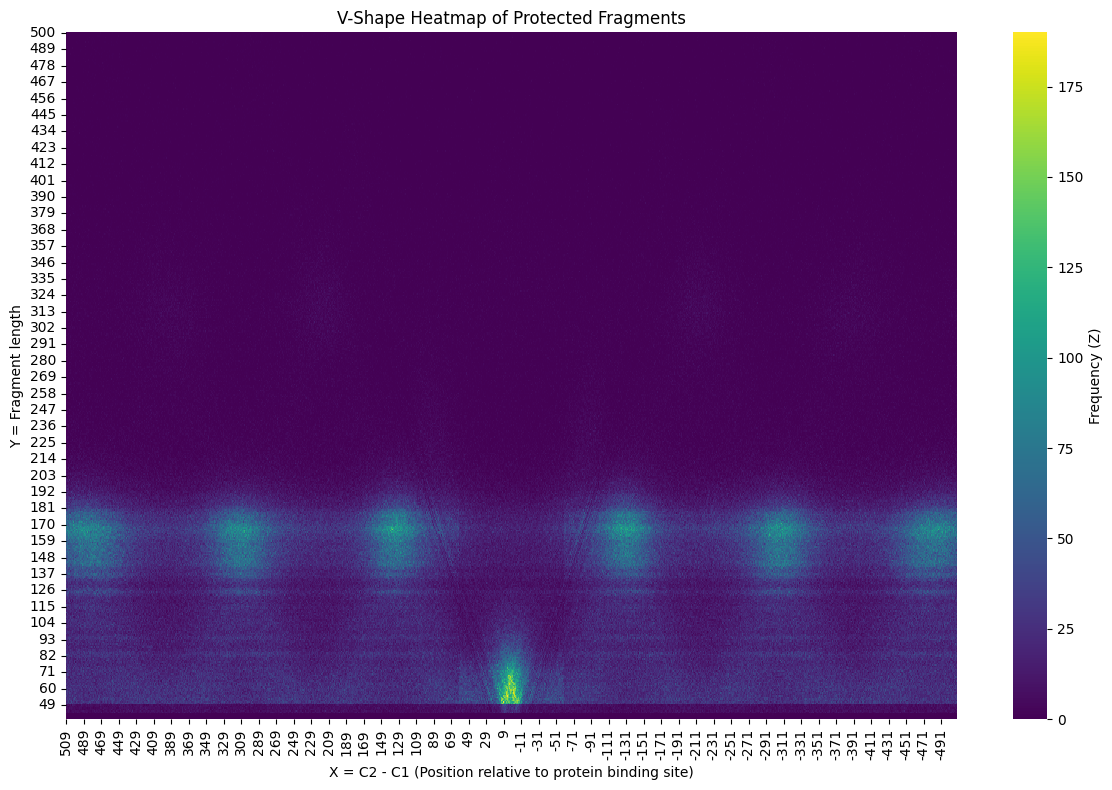

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = "mapped.bed"
with open(file_path, 'rt') as f:
    df = pd.read_csv(f, sep='\t', header=None)

C1 = (df[2] + df[3]) // 2
C2 = (df[8] + df[9]) // 2

df['X'] = C2 - C1
df['Y'] = df[9] - df[8]

heatmap_data = df.groupby(['X', 'Y']).size().reset_index(name='Z')

heatmap_pivot = heatmap_data.pivot(index='Y', columns='X', values='Z').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot[::-1].iloc[:, ::-1], cmap='viridis', cbar_kws={'label': 'Frequency (Z)'})
plt.title("V-Shape Heatmap of Protected Fragments")
plt.xlabel("X = C2 - C1 (Position relative to protein binding site)")
plt.ylabel("Y = Fragment length")
plt.tight_layout()
plt.show()
